In [23]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ['GROQ_API_KEY']:
    print("Groq API Key Set!")
else:
    raise ValueError("Groq API Key is not set!!")

Groq API Key Set!


In [24]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "openai/gpt-oss-20b")

llm.invoke("Hello!").content    

'Hello! How can I help you today?'

## **PYDANTIC SCHEMA**

In [25]:
from typing import TypedDict

class graph_schema(TypedDict):

    topic : str
    insta : str
    twitter : str
    linkedin : str

In [26]:
def create_post_insta(state : graph_schema) -> graph_schema:

    topic = state['topic']
    post = llm.invoke(f"Write a instagram post for {topic}. Keep the tone casual & engaging").content
    state['insta'] = post
    return {'insta': post}

def create_post_twitter(state : graph_schema) -> graph_schema:

    topic = state['topic']
    post = llm.invoke(f"Write a twitter post for {topic}. Keep the tone quick.").content
    state['twitter'] = post
    return {'twitter': post}

def create_post_linkedin(state : graph_schema) -> graph_schema:

    topic = state['topic']
    post = llm.invoke(f"Write a linkedin post for {topic}. Keep the tone professional & informative").content
    state['linkedin'] = post
    return {'linkedin': post}

In [27]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

graph.add_edge(START,"create_post_insta")
graph.add_edge(START,"create_post_twitter")
graph.add_edge(START,"create_post_linkedin")
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

parallel_graph = graph.compile()

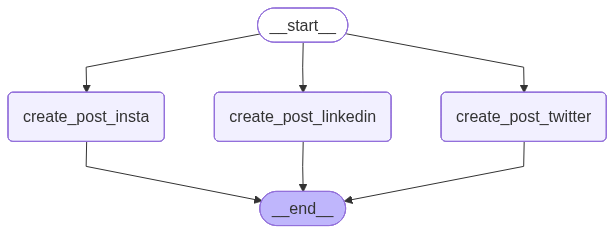

In [28]:
from IPython.display import Image,display

Image(parallel_graph.get_graph().draw_mermaid_png())

In [29]:
parallel_graph.invoke(
    {"topic":"Artificial Intelligence",
    "create_post_insta":"",
    "create_post_twitter":"",
    "create_post_linkedin":""}
)

{'topic': 'Artificial Intelligence',
 'insta': '🚀🤖 **AI is the new BFF of everyday life!**  \n\nFrom the playlist that *knows* exactly what you’re feeling, to the smart fridge that’s basically a foodie‑oracle, Artificial Intelligence is quietly (and sometimes loudly) making our world a bit smarter and a lot more fun.  \n\n**Did you know?**  \n- A single neural‑network model can generate poems, code, and even help doctors spot early signs of disease.  \n- Some AIs are now creating artwork that’s so good, people are paying for prints!  \n\nSo whether you’re a tech‑geek, a creative soul, or just someone who loves a good recommendation, AI’s got something for you.  \n\n💬 **Tell me**: What’s the coolest AI tool you’ve used this week? Drop a comment below and let’s geek out together!  \n\n#AI #ArtificialIntelligence #TechTalk #FutureIsNow #Innovation #SmartTech #GeekLife #StayCurious 🚀✨',
 'twitter': '🤖🚀 AI is rewriting tomorrow—one line of code at a time. From chatbots to self‑driving cars,